Campo generado. Rango: min=1.00e-04, max=9.82e+03


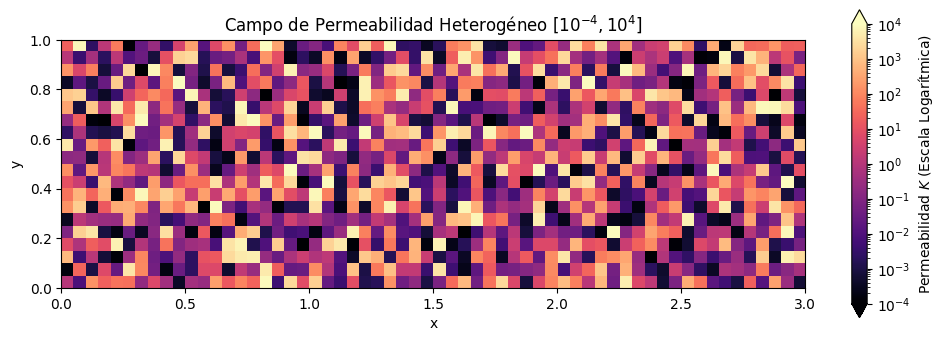

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# --- Configuración del Dominio ---
x_min, x_max = 0.0, 3.0
y_min, y_max = 0.0, 1.0
Nx, Ny = 60, 20 

# --- Generación del Campo con Rango Específico [1e-4, 1e4] ---
# Generamos una distribución uniforme o normal en el espacio logarítmico
# Queremos que el exponente base 10 varíe entre -4 y 4
log_K = np.random.uniform(-4, 4, size=(Ny, Nx))
K_grid = 10**log_K

# Aplanamos para FreeFem++
K_flat = K_grid.flatten()
np.savetxt("K_grid.dat", K_flat, fmt="%.8e") # Usamos formato científico para precisión

print(f"Campo generado. Rango: min={K_grid.min():.2e}, max={K_grid.max():.2e}")

# --- Visualización con Escala Logarítmica ---
plt.figure(figsize=(12, 4))

# Usamos LogNorm para que el color represente los órdenes de magnitud correctamente
img = plt.imshow(K_grid, 
                 extent=[x_min, x_max, y_min, y_max], 
                 origin='lower', 
                 cmap='magma', # 'magma' o 'viridis' funcionan bien para contrastes altos
                 norm=LogNorm(vmin=1e-4, vmax=1e4),
                 aspect='equal')

cbar = plt.colorbar(img, extend='both')
cbar.set_label('Permeabilidad $K$ (Escala Logarítmica)')

plt.title('Campo de Permeabilidad Heterogéneo $[10^{-4}, 10^{4}]$')
plt.xlabel('x')
plt.ylabel('y')

#plt.savefig("permeability_field_log.png", dpi=300)
plt.show()